In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("telco_churn.csv")


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

print("Starting shape:", df.shape)
df.head()

Starting shape: (7032, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
df = df.drop(columns=['customerID'])
print("Dropped customerID.New shape:", df.shape)

Dropped customerID.New shape: (7032, 20)


In [13]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn value counts:")
print(df['Churn'].value_counts())

Churn value counts:
0    5163
1    1869
Name: Churn, dtype: int64


In [14]:

print(df['SeniorCitizen'].value_counts())


0    5890
1    1142
Name: SeniorCitizen, dtype: int64


In [15]:
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 
    'PaperlessBilling', 'MultipleLines',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'No phone service': 0, 'No internet service': 0})

print("Binary columns encoded")
df[binary_cols].head()

Binary columns encoded


,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,1,0,0,1,0,0,1,0,0,0,0
1,0,0,1,0,0,1,0,1,0,0,0
2,0,0,1,1,0,1,1,0,0,0,0
3,0,0,0,0,0,1,0,1,1,0,0
4,0,0,1,1,0,0,0,0,0,0,0


In [16]:
multi_cols = ['gender', 'InternetService', 'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print("Shape after encoding:", df.shape)
print("New columns added:")
print([c for c in df.columns if any(m in c for m in multi_cols)])

Shape after encoding: (7032, 24)
New columns added:
['gender_Male', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [17]:
# Feature 1: Charge per month relative to how long they've been a customer
# High ratio = paying a lot but still new = higher churn risk
df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

# Feature 2: How many add-on services does the customer have?
# More services = more embedded = less likely to leave
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
df['total_services'] = df[service_cols].sum(axis=1)

# Feature 3: Is this customer a high spender?
df['high_spender'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

print("New features created")
print(df[['charges_per_tenure', 'total_services', 'high_spender']].describe().round(2))

New features created
       charges_per_tenure  total_services  high_spender
count             7032.00         7032.00        7032.0
mean                 5.71            2.04           0.5
std                  8.57            1.85           0.5
min                  0.26            0.00           0.0
25%                  1.25            0.00           0.0
50%                  2.07            2.00           0.0
75%                  5.88            3.00           1.0
max                 51.22            6.00           1.0


In [8]:
print("=== FINAL SHAPE ===")
print(df.shape)

print("\n=== ANY NULLS LEFT? ===")
print(df.isnull().sum().sum(), "nulls remaining")

print("\n=== ALL COLUMNS ===")
print(df.columns.tolist())


df.to_csv("telco_churn_clean.csv", index=False)
print("\n Saved as telco_churn_clean.csv — ready for modeling!")

=== FINAL SHAPE ===
(7032, 27)

=== ANY NULLS LEFT? ===
0 nulls remaining

=== ALL COLUMNS ===
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'gender_Male', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check', 'charges_per_tenure', 'total_services', 'high_spender']

 Saved as telco_churn_clean.csv — ready for modeling!


<ipython-input-9-41d0d2e3f6a4>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='total_services',


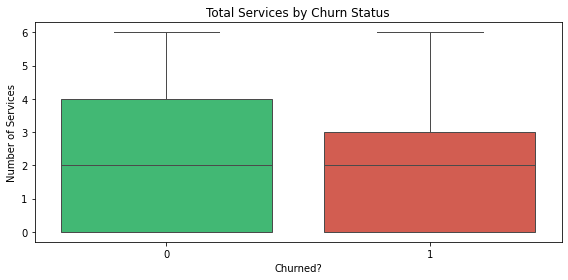

Churn
0    2.14
1    1.77
Name: total_services, dtype: float64


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Churn', y='total_services', 
            palette=['#2ecc71', '#e74c3c'])
plt.title('Total Services by Churn Status')
plt.xlabel('Churned?')
plt.ylabel('Number of Services')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['total_services'].mean().round(2))